# Graphic 2: GISTEMP Seasonal Cycle since 1880
Replication of NASA GISS's chart of monthly temperature anomalies, with one line per year from 1880 to today, colored by year.

## 1. Setup
Import the libraries and define paths relative to the repo root, since this notebook runs from `scripts/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize


ROOT = Path.cwd().parent
DATA = ROOT /"data"
OUT = ROOT /"outputs"
OUT.mkdir(exist_ok=True)

## 2. Load the data
The CSV starts with a title line and a `Year,Anomaly` header, so we skip both and name the columns ourselves. The year is a decimal year (e.g. 1880.04 = January 1880), so each row is one month.

In [2]:
df = pd.read_csv(DATA / "graphic2_seasonal_cycle.csv", skiprows= 2,names= ["decimal_year", "anomaly"])

df.head()

,decimal_year,anomaly
0,1880.04,-2.61
1,1880.13,-2.42
2,1880.21,-1.58
3,1880.29,-0.64
4,1880.38,0.36


## 3. Inspect and clean
Split the decimal year into a calendar year and a month. The fractional part is the middle of each month (0.04 = Jan, 0.13 = Feb, ..., 0.96 = Dec), so multiplying it by 12 and rounding down gives the month index.

In [3]:
df = df.apply(pd.to_numeric, errors= "coerce").dropna()  # non-numeric become NaN
df["year"] = np.floor(df["decimal_year"]).astype(int)
df["month"] = ((df["decimal_year"] - df["year"]) * 12).astype(int) + 1

print(df.shape)
print(df["month"].value_counts().sort_index())
df.groupby("year").size().tail(3)

(1760, 4)
month
1     147
2     147
3     147
4     147
5     147
6     147
7     147
8     147
9     146
10    146
11    146
12    146
Name: count, dtype: int64


year
2024    12
2025    12
2026     8
dtype: int64

In [4]:
# One row per month, one column per year
seasonal = df.pivot(index="month", columns="year", values="anomaly")

seasonal.iloc[:, -3:]

year,2024,2025,2026
month,,,
1,-1.17,-1.04,-1.33
2,-0.72,-0.90,-0.91
3,-0.08,-0.11,-0.16
4,0.85,0.78,0.70
5,1.63,1.55,1.60
6,2.38,2.22,2.33
7,2.62,2.44,2.67
8,2.59,2.47,2.69
9,1.87,1.91,NaN


## 4. Create the plot
A function that draws one line per year, colored from blue (1880) through green, orange and red to purple (latest year). The latest year is drawn thicker with black dots, like NASA's chart.

In [5]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
# Approximation of NASA's year colors, one stop per ~20 years:
# blue -> teal -> green -> gold -> orange -> dark red
YEAR_CMAP = LinearSegmentedColormap.from_list(
    "nasa_like", ["#4B5FE8", "#4A7FD6", "#5AA5B5", "#83BF8E",
                  "#A5BE62", "#C59A45", "#E0743D", "#A8322A"])
LATEST_COLOR = "#6A1B9A"  # NASA draws the current year in purple


def plot_seasonal_cycle(seasonal):
    """Recreate NASA's seasonal cycle chart: one line per year, colored by year."""
    years = seasonal.columns
    latest = years.max()
    norm = Normalize(vmin=years.min(), vmax=latest - 1)  # maps a year to 0-1 for the colormap
    legend_years = list(range(1880, 2021, 20))

    fig, ax = plt.subplots(figsize=(11, 7))
    for year in years[years != latest]:
        label = str(year) if year in legend_years else None
        ax.plot(seasonal.index, seasonal[year], color=YEAR_CMAP(norm(year)),
                linewidth=1.5, label=label)
    # Latest (partial) year on top: purple line, plus black dots kept out of the legend
    ax.plot(seasonal.index, seasonal[latest], color=LATEST_COLOR,
            linewidth=1.5, label=str(latest))
    ax.plot(seasonal.index, seasonal[latest], linestyle="none", marker="o",
            markersize=6, color="black")

    ax.set_title("GISTEMP Seasonal Cycle since 1880", fontsize=16)
    ax.set_ylabel("Temperature Anomaly w.r.t. 1980-2015 (°C)", fontsize=14)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=14)
    ax.set_xlim(0.5, 12.5)
    ax.set_yticks(np.arange(-4.0, 3.01, 0.5))  # a tick every 0.5 °C
    ax.yaxis.set_major_formatter("{x:.1f}")      # labels like -4.0, -3.5, ..., 3.0
    ax.set_ylim(-4.0, 3.0)
    ax.legend(loc="upper left", frameon=True, fontsize=11,
              labelcolor="linecolor")  # legend text in each line's color
    ax.spines[["top", "right"]].set_visible(False)
    ax.text(0.99, 0.02, "Seasonal cycle from MERRA2. Figure: NASA/GISS/GISTEMP v4",
            transform=ax.transAxes, ha="right", fontsize=13, color="#333333")
    return fig, ax

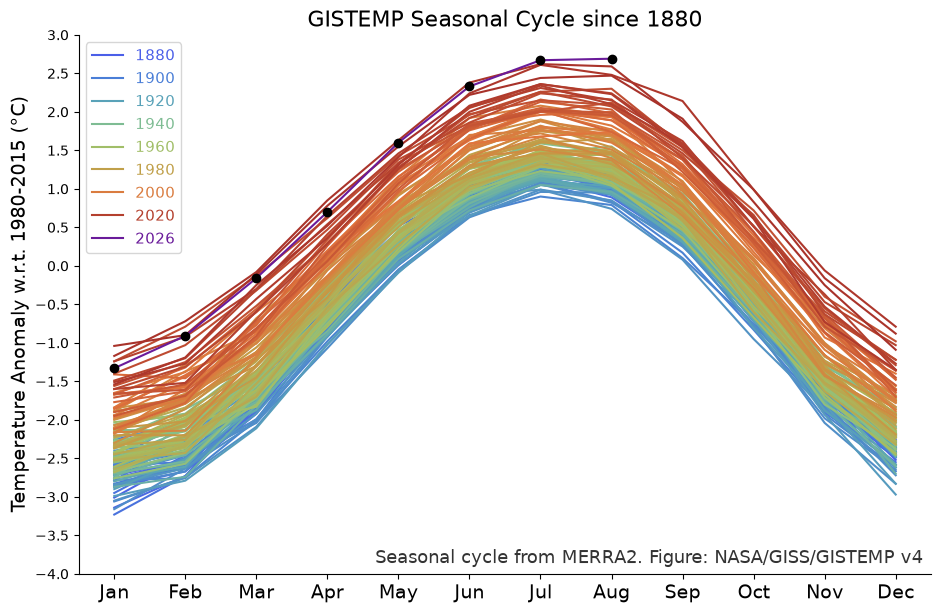

In [6]:
fig, ax = plot_seasonal_cycle(seasonal)

plt.show()

## 5. Save the figure
Save the figure to `outputs/` as both PNG and PDF.

In [7]:
fig.savefig(OUT / "graphic2_seasonal_cycle.png", dpi= 300, bbox_inches= "tight")

fig.savefig(OUT / "graphic2_seasonal_cycle.pdf", bbox_inches= "tight", metadata= {"CreationDate": None})

## 6. Notes
Every year follows the same seasonal shape, coldest in Dec-Feb and warmest in Jul-Aug, but the whole curve has shifted upward over time: recent years sit well above the 1880s in every month. Differences from NASA's chart: the colormap is an approximation of NASA's, fonts are matplotlib defaults, and 2026 only has data through August.